# Phân tích các yếu tố ảnh hưởng đến rating của phim

---

## 1. Phát biểu bài toán

**Mục tiêu:** Phân tích dữ liệu phim nhằm khảo sát **tính khả thi** cho việc xây dựng mô hình **dự đoán rating của phim** (biến mục tiêu \(Y\)) từ các biến/đặc trưng (predictors) như: năm phát hành, số lượt bình chọn, thể loại, thời lượng, ngân sách, v.v.

- **Loại bài toán:** **Hồi quy (regression)** — vì \(Y\) (rating) là biến số thực (thang điểm, 0–10).
- **Câu hỏi cần trả lời:**
  1. Bài toán dự đoán rating từ các yếu tố trên **có khả thi về mặt dữ liệu** hay không? Vì sao?
  2. Nếu khả thi, **tập đặc trưng hữu ích** nào có thể dùng để xây dựng mô hình?

*(Lưu ý: Phần mô hình hóa sẽ thực hiện ở bài tập sau; bài thi GK chỉ dừng ở phân tích, làm sạch, trực quan hóa và đánh giá khả thi.)*

## 2. Thu thập dữ liệu

- **Nguồn:** [The Movie Database (TMDB)](https://www.themoviedb.org) — danh sách phim và thông tin chi tiết qua TMDB API.
- **Cách thu thập:** Script `scrape.py`:
  1. Lấy danh sách link phim từ các trang listing (vd: `https://www.themoviedb.org/movie?page=1`).
  2. Với mỗi phim, trích `movie_id` từ URL và gọi TMDB API (`/movie/{id}`) để lấy: tên phim, năm phát hành, rating, số vote, thể loại, runtime, budget.
  3. Chỉ lưu bản ghi đủ thông tin (không có trường N/A).
- **Số mẫu:** >1000 (tùy số trang crawl). **Số biến:** 7 (Movie_name, Release_year, Rating, Voting_count, Genre, Run_time, Budget).

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

# Thiết lập đồ thị: matplotlib + seaborn
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')
sns.set_palette('husl')

# Đường dẫn: chạy từ thư mục notebooks/ (RAW_PATH = ../raw data/data.xlsx)
RAW_PATH = os.path.join('..', 'raw data', 'data.xlsx')
if not os.path.exists(RAW_PATH):
    RAW_PATH = os.path.join('raw data', 'data.xlsx')
CLEAN_DIR = os.path.join('..', 'clean data') if os.path.exists(os.path.join('..', 'raw data')) else os.path.join('clean data')
os.makedirs(CLEAN_DIR, exist_ok=True)
CLEAN_PATH = os.path.join(CLEAN_DIR, 'movies_clean.csv')

df = pd.read_excel(RAW_PATH)
# Loại bỏ cột index không tên (nếu có) khi đọc từ Excel
if df.columns[0] == 'Unnamed: 0' or (df.columns[0] != 'Movie_name' and 'Movie_name' in df.columns):
    df = df.drop(columns=[c for c in df.columns if 'Unnamed' in str(c)], errors='ignore')
print('Kích thước:', df.shape)
print('Các cột:', list(df.columns))
df.head(10)

Kích thước: (1826, 7)
Các cột: ['Movie_name', 'Release_year', 'Rating', 'Voting_count', 'Genre', 'Run_time', 'Budget']


,Movie_name,Release_year,Rating,Voting_count,Genre,Run_time,Budget
0,Life Is Beautiful,1997,8.4,13846.0,"Comedy, Drama",116 min,"$20,000,000"
1,Cinderella,2015,6.8,7337.0,"Romance, Fantasy, Family, Drama",105 min,"$95,000,000"
2,My Neighbor Totoro,1988,8.1,8672.0,"Fantasy, Animation, Family",86 min,"$3,700,000"
3,Everything Everywhere All at Once,2022,7.7,7735.0,"Action, Adventure, Science Fiction",140 min,"$25,000,000"
4,The Hobbit: The Desolation of Smaug,2013,7.6,13998.0,"Fantasy, Adventure, Action",161 min,"$250,000,000"
5,Downton Abbey: A New Era,2022,7.2,596.0,"Drama, Romance",124 min,"$40,000,000"
6,Madagascar,2005,6.9,11581.0,"Family, Animation, Adventure, Comedy",86 min,"$75,000,000"
7,Captain America: Civil War,2016,7.4,23806.0,"Adventure, Action, Science Fiction",147 min,"$250,000,000"
8,Scouts Guide to the Zombie Apocalypse,2015,6.6,2093.0,"Comedy, Horror",93 min,"$15,000,000"
9,Platoon,1986,7.7,5007.0,"Drama, War, Action",120 min,"$6,000,000"


### 2.1 Thống kê mô tả và thông tin dataset

In [33]:
print('=== Thông tin dataset ===')
df.info()
print('\n=== Kiểu dữ liệu ===')
print(df.dtypes)
print('\n=== Missing values ===')
print(df.isnull().sum())
print('\n=== Thống kê mô tả (biến số) ===')
print(df.describe(include=[np.number]))
print('\n=== Thống kê mô tả (tất cả) ===')
df.describe(include='all')

=== Thông tin dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1826 entries, 0 to 1825
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Movie_name    1826 non-null   object 
 1   Release_year  1826 non-null   int64  
 2   Rating        1822 non-null   float64
 3   Voting_count  1822 non-null   float64
 4   Genre         1823 non-null   object 
 5   Run_time      1821 non-null   object 
 6   Budget        1826 non-null   object 
dtypes: float64(2), int64(1), object(4)
memory usage: 100.0+ KB

=== Kiểu dữ liệu ===
Movie_name       object
Release_year      int64
Rating          float64
Voting_count    float64
Genre            object
Run_time         object
Budget           object
dtype: object

=== Missing values ===
Movie_name      0
Release_year    0
Rating          4
Voting_count    4
Genre           3
Run_time        5
Budget          0
dtype: int64

=== Thống kê mô tả (biến số) ===
       Release_y

,Movie_name,Release_year,Rating,Voting_count,Genre,Run_time,Budget
count,1826,1826.000000,1822.000000,1822.000000,1823,1821,1826
unique,1798,NaN,NaN,NaN,719,154,404
top,The Jungle Book,NaN,NaN,NaN,Drama,102 min,"$15,000,000"
freq,2,NaN,NaN,NaN,70,46,53
mean,NaN,2006.979737,6.803183,5497.012075,NaN,NaN,NaN
std,NaN,16.895914,1.100332,6037.050733,NaN,NaN,NaN
min,NaN,1916.000000,0.000000,0.000000,NaN,NaN,NaN
25%,NaN,2000.000000,6.400000,919.250000,NaN,NaN,NaN
50%,NaN,2011.000000,6.900000,3568.000000,NaN,NaN,NaN
75%,NaN,2019.000000,7.500000,7905.500000,NaN,NaN,NaN


### 2.2 Trực quan hóa đơn biến (một số biến quan trọng)

Ví dụ: **Rating** (biến mục tiêu), **Voting_count**, **Release_year**, **Genre** (phổ biến).

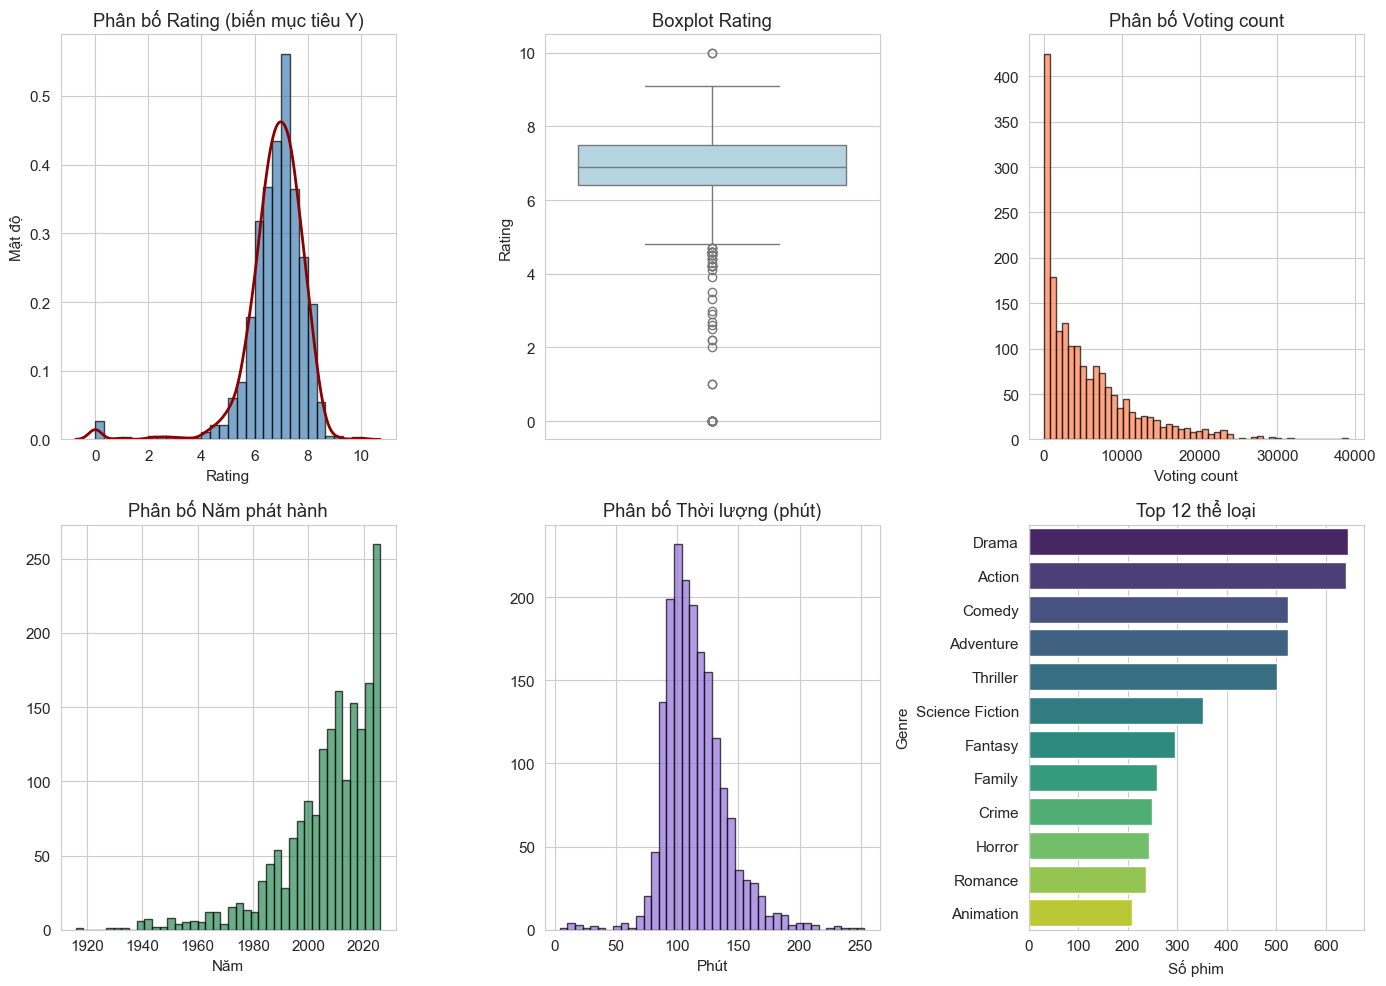

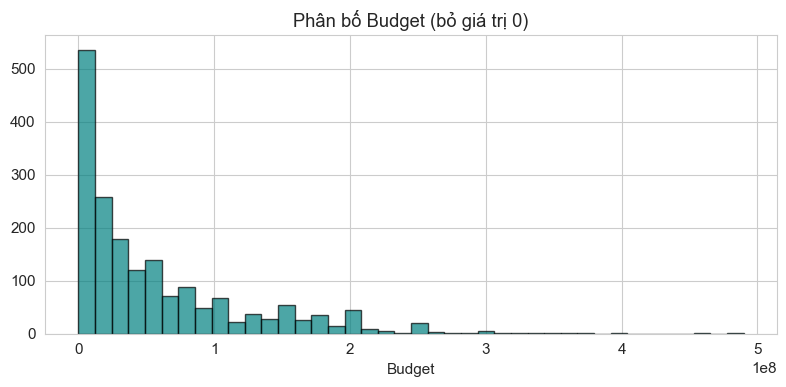

In [34]:
# Chuẩn hóa kiểu để vẽ: Rating, Voting_count, Release_year; parse Run_time, Budget
df_plot = df.copy()
df_plot['Rating'] = pd.to_numeric(df_plot['Rating'], errors='coerce')
df_plot['Voting_count'] = pd.to_numeric(df_plot['Voting_count'], errors='coerce')
df_plot['Release_year'] = pd.to_numeric(df_plot['Release_year'], errors='coerce')
# Run_time: "116 min" -> 116
df_plot['Run_time_num'] = df_plot['Run_time'].astype(str).str.replace(' min', '').str.replace(',', '')
df_plot['Run_time_num'] = pd.to_numeric(df_plot['Run_time_num'], errors='coerce')
# Budget: "$20,000,000" -> 20000000
df_plot['Budget_num'] = df_plot['Budget'].astype(str).str.replace('$', '').str.replace(',', '')
df_plot['Budget_num'] = pd.to_numeric(df_plot['Budget_num'], errors='coerce')

# --- Trực quan đơn biến: 6 đồ thị (matplotlib + seaborn) ---
fig, axes = plt.subplots(2, 3, figsize=(14, 10))

# 1. Phân bố Rating (histogram + KDE)
axes[0,0].hist(df_plot['Rating'].dropna(), bins=30, edgecolor='black', alpha=0.7, density=True, color='steelblue')
sns.kdeplot(df_plot['Rating'].dropna(), ax=axes[0,0], color='darkred', linewidth=2)
axes[0,0].set_title('Phân bố Rating (biến mục tiêu Y)')
axes[0,0].set_xlabel('Rating')
axes[0,0].set_ylabel('Mật độ')

# 2. Boxplot Rating
sns.boxplot(y=df_plot['Rating'], ax=axes[0,1], color='lightblue')
axes[0,1].set_title('Boxplot Rating')
axes[0,1].set_ylabel('Rating')

# 3. Phân bố Voting_count (histogram)
df_plot['Voting_count'].dropna().hist(ax=axes[0,2], bins=50, edgecolor='black', alpha=0.7, color='coral')
axes[0,2].set_title('Phân bố Voting count')
axes[0,2].set_xlabel('Voting count')

# 4. Phân bố Release_year
df_plot['Release_year'].dropna().hist(ax=axes[1,0], bins=40, edgecolor='black', alpha=0.7, color='seagreen')
axes[1,0].set_title('Phân bố Năm phát hành')
axes[1,0].set_xlabel('Năm')

# 5. Phân bố Run_time (phút)
df_plot['Run_time_num'].dropna().hist(ax=axes[1,1], bins=40, edgecolor='black', alpha=0.7, color='mediumpurple')
axes[1,1].set_title('Phân bố Thời lượng (phút)')
axes[1,1].set_xlabel('Phút')

# 6. Top thể loại (bar horizontal - seaborn)
genre_counts = df['Genre'].str.split(', ').explode().str.strip().value_counts().head(12)
sns.barplot(x=genre_counts.values, y=genre_counts.index, ax=axes[1,2], palette='viridis')
axes[1,2].set_title('Top 12 thể loại')
axes[1,2].set_xlabel('Số phim')
plt.tight_layout()
plt.show()

# Phân bố Budget (nhiều giá trị 0 hoặc nhỏ, vẽ riêng)
fig, ax = plt.subplots(1, 1, figsize=(8, 4))
budget_valid = df_plot['Budget_num'].dropna()
budget_valid = budget_valid[budget_valid > 0]
budget_valid.hist(ax=ax, bins=40, edgecolor='black', alpha=0.7, color='teal')
ax.set_title('Phân bố Budget (bỏ giá trị 0)')
ax.set_xlabel('Budget')
plt.tight_layout()
plt.show()

## 3. Làm sạch và chuẩn hóa dữ liệu (Data cleaning)

**Các bước xử lý:**

1. **Kiểm tra missing & duplicate:** Đếm missing từng cột; loại bản ghi trùng lặp (nếu có).
2. **Chuẩn hóa kiểu dữ liệu:**
   - `Rating`, `Voting_count`, `Release_year` → số (numeric).
   - `Run_time`: bỏ hậu tố `" min"` và chuyển sang số (phút) → cột `Runtime_min`.
   - `Budget`: bỏ `$` và dấu phẩy, chuyển sang số → cột `Budget_num`.
3. **Xử lý missing:** Loại các dòng thiếu giá trị ở biến quan trọng (Rating, Voting_count, Release_year); với Runtime và Budget có thể giữ missing hoặc điền (tùy chiến lược).
4. **Giá trị bất thường:** Loại hoặc giới hạn outlier nếu cần (vd: Runtime &lt; 30 hoặc &gt; 300 phút, năm ngoài khoảng hợp lý).
5. **Chuỗi:** Chuẩn hóa khoảng trắng, strip ký tự thừa ở `Genre`, `Movie_name`.

Sau đây **trực quan hóa phân bố trước và sau làm sạch** để thấy sự thay đổi.

In [ ]:
# --- Bước 1: Kiểm tra missing và duplicate ---
print('Số bản ghi trùng lặp:', df.duplicated().sum())
print('Missing trước làm sạch:')
print(df.isnull().sum())

def parse_runtime(s):
    if pd.isna(s): return np.nan
    s = str(s).replace(' min', '').replace(',', '').strip()
    try: return float(s)
    except: return np.nan

def parse_budget(s):
    if pd.isna(s): return np.nan
    s = str(s).replace('$', '').replace(',', '').strip()
    try: return float(s)
    except: return np.nan

# --- Bước 2 & 3: Chuẩn hóa kiểu và tạo cột số ---
df_clean = df.copy()
df_clean['Rating'] = pd.to_numeric(df_clean['Rating'], errors='coerce')
df_clean['Voting_count'] = pd.to_numeric(df_clean['Voting_count'], errors='coerce')
df_clean['Release_year'] = pd.to_numeric(df_clean['Release_year'], errors='coerce')
df_clean['Runtime_min'] = df_clean['Run_time'].apply(parse_runtime)
df_clean['Budget_num'] = df_clean['Budget'].apply(parse_budget)

# Loại bản ghi thiếu biến mục tiêu hoặc biến quan trọng
df_clean = df_clean.dropna(subset=['Rating', 'Voting_count', 'Release_year'])
# Loại bản ghi có Rating ngoài [0, 10] hoặc Voting_count < 100 (ít vote, thông tin không đáng tin cậy)
df_clean = df_clean[(df_clean['Rating'] >= 0) & (df_clean['Rating'] <= 10) & (df_clean['Voting_count'] >= 100)]
# Runtime hợp lý: 30–300 phút (hoặc giữ NaN nếu không có)
df_clean.loc[(df_clean['Runtime_min'].notna()) & ((df_clean['Runtime_min'] < 30) | (df_clean['Runtime_min'] > 300)), 'Runtime_min'] = np.nan
# Năm hợp lý: 1900–năm hiện tại
from datetime import datetime
current_year = datetime.now().year
df_clean = df_clean[(df_clean['Release_year'] >= 1900) & (df_clean['Release_year'] <= current_year)]
# Chuẩn hóa chuỗi
df_clean['Genre'] = df_clean['Genre'].astype(str).str.strip()
df_clean['Movie_name'] = df_clean['Movie_name'].astype(str).str.strip()
df_clean = df_clean.drop_duplicates()

print('\nShape sau làm sạch:', df_clean.shape)
print('Missing sau làm sạch (các cột chính):')
print(df_clean[['Rating', 'Voting_count', 'Release_year', 'Runtime_min', 'Budget_num']].isnull().sum())

Số bản ghi trùng lặp: 0
Missing trước làm sạch:
Movie_name      0
Release_year    0
Rating          4
Voting_count    4
Genre           3
Run_time        5
Budget          0
dtype: int64

Shape sau làm sạch: (1656, 9)
Missing sau làm sạch (các cột chính):
Rating          0
Voting_count    0
Release_year    0
Runtime_min     4
Budget_num      0
dtype: int64


### Trực quan: phân bố trước và sau làm sạch

So sánh phân bố của **Rating**, **Voting_count** và **Release_year** trước và sau bước làm sạch (loại missing, giá trị bất thường, duplicate) để thấy sự thay đổi.

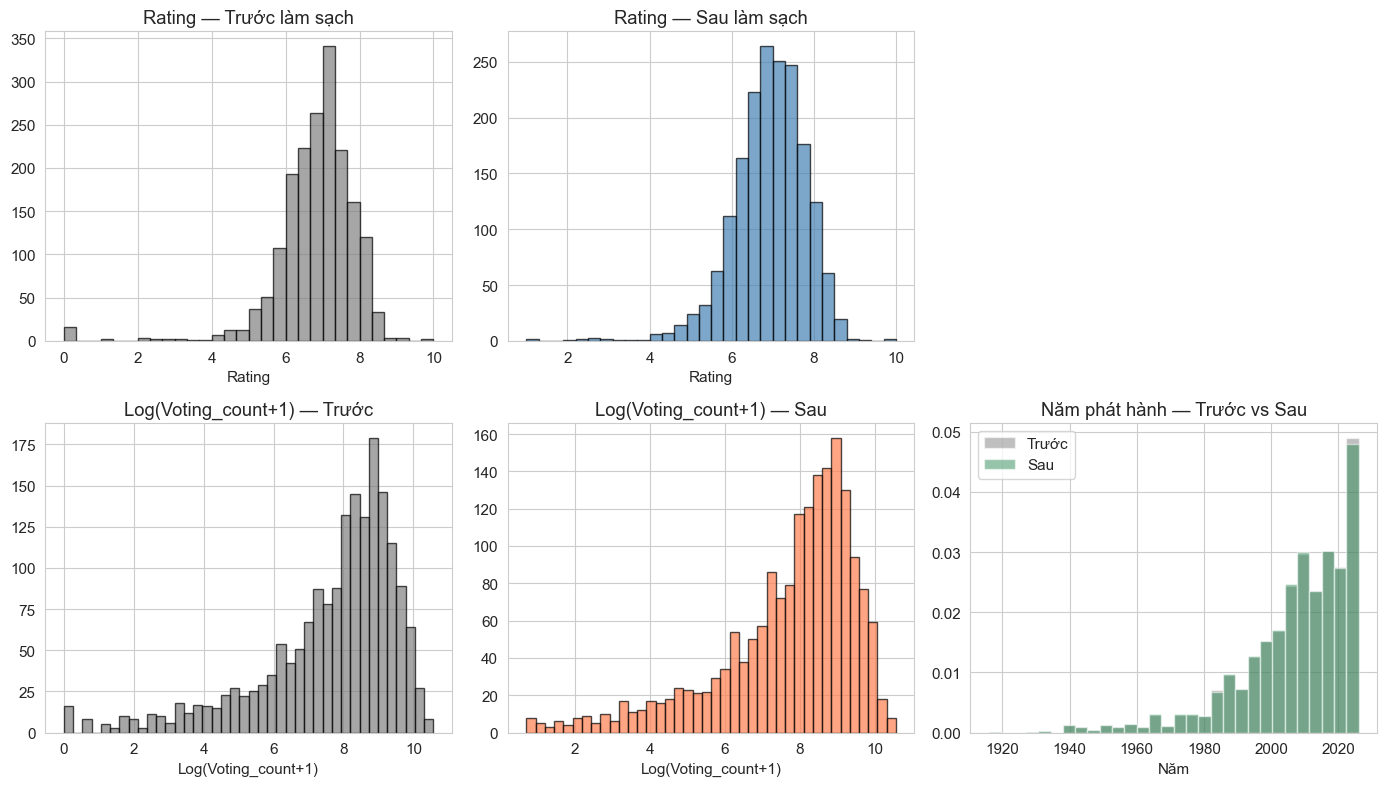

In [39]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

# Rating
axes[0,0].hist(df_plot['Rating'].dropna(), bins=30, alpha=0.7, color='gray', edgecolor='black')
axes[0,0].set_title('Rating — Trước làm sạch')
axes[0,0].set_xlabel('Rating')
axes[0,1].hist(df_clean['Rating'], bins=30, alpha=0.7, color='steelblue', edgecolor='black')
axes[0,1].set_title('Rating — Sau làm sạch')
axes[0,1].set_xlabel('Rating')
axes[0,2].axis('off')

# Voting_count (dùng log scale để dễ so sánh)
vc_before = np.log1p(df_plot['Voting_count'].dropna())
vc_after = np.log1p(df_clean['Voting_count'])
axes[1,0].hist(vc_before, bins=40, alpha=0.7, color='gray', edgecolor='black')
axes[1,0].set_title('Log(Voting_count+1) — Trước')
axes[1,0].set_xlabel('Log(Voting_count+1)')
axes[1,1].hist(vc_after, bins=40, alpha=0.7, color='coral', edgecolor='black')
axes[1,1].set_title('Log(Voting_count+1) — Sau')
axes[1,1].set_xlabel('Log(Voting_count+1)')
# Release_year
axes[1,2].hist(df_plot['Release_year'].dropna(), bins=30, alpha=0.5, color='gray', label='Trước', density=True)
axes[1,2].hist(df_clean['Release_year'], bins=30, alpha=0.5, color='seagreen', label='Sau', density=True)
axes[1,2].set_title('Năm phát hành — Trước vs Sau')
axes[1,2].set_xlabel('Năm')
axes[1,2].legend()
plt.tight_layout()
plt.show()

## 4. Mã hóa dữ liệu (Encoding)

- **Thể loại (Genre):** danh mục — có thể dùng one-hot encoding hoặc đếm số thể loại mỗi phim, hoặc embedding thể loại.
- **Text (Movie_name, mô tả nếu có):** có thể vector hóa (TF-IDF, BoW) nếu cần feature từ text; với bài này có thể bỏ qua hoặc chỉ dùng độ dài tên.

Thêm ô code thực hiện encoding và giải thích ngắn trong Markdown.

In [ ]:
# --- Mã hóa thể loại (Genre): One-hot encoding cho top thể loại ---
# Tách từng thể loại (phân tách bằng ", ") và đếm tần suất
genres_flat = df_clean['Genre'].str.split(', ').explode().str.strip()
top_genres = genres_flat.value_counts().head(12).index.tolist()
for g in top_genres:
    col_name = 'Genre_' + g.replace(' ', '_').replace('&', 'and')
    df_clean[col_name] = df_clean['Genre'].str.contains(g, regex=False, na=False).astype(int)

genre_cols = [c for c in df_clean.columns if c.startswith('Genre_')]
print('Số cột one-hot thể loại:', len(genre_cols))
print('Ví dụ:', genre_cols[:5])
df_clean[['Genre'] + genre_cols[:5]].head(8)

Số cột one-hot thể loại: 12
Ví dụ: ['Genre_Action', 'Genre_Drama', 'Genre_Adventure', 'Genre_Comedy', 'Genre_Thriller']


,Genre,Genre_Action,Genre_Drama,Genre_Adventure,Genre_Comedy,Genre_Thriller
0,"Comedy, Drama",0,1,0,1,0
1,"Romance, Fantasy, Family, Drama",0,1,0,0,0
2,"Fantasy, Animation, Family",0,0,0,0,0
3,"Action, Adventure, Science Fiction",1,0,1,0,0
4,"Fantasy, Adventure, Action",1,0,1,0,0
5,"Drama, Romance",0,1,0,0,0
6,"Family, Animation, Adventure, Comedy",0,0,1,1,0
7,"Adventure, Action, Science Fiction",1,0,1,0,0


## 5. Xây dựng và lựa chọn đặc trưng (Feature engineering)

Các đặc trưng đã xây dựng:
- **Num_genres:** Số lượng thể loại mỗi phim (từ cột Genre).
- **Voting_count_log:** Log(1 + Voting_count) để giảm độ lệch phân bố.
- **Decade:** Thập kỷ phát hành (1900, 1910, …) — biến có thứ tự.
- **Title_length:** Độ dài tên phim (feature đơn giản từ text).
- **Budget_log:** Log(1 + Budget) cho phim có ngân sách (nhiều giá trị 0).

In [ ]:
# Số lượng thể loại mỗi phim (sau khi tách bằng dấu phẩy)
df_clean['Num_genres'] = df_clean['Genre'].str.split(',').str.len().fillna(0).astype(int)
# Log(Voting_count + 1) để giảm độ lệch (distribution skew)
df_clean['Voting_count_log'] = np.log1p(df_clean['Voting_count'])
# Thập kỷ phát hành (decade) — biến danh mục có thứ tự
df_clean['Decade'] = (df_clean['Release_year'] // 10) * 10
# Độ dài tên phim (feature từ text đơn giản)
df_clean['Title_length'] = df_clean['Movie_name'].str.len()
# Budget log (nếu có, nhiều giá trị 0 nên dùng log1p)
df_clean['Budget_log'] = np.log1p(df_clean['Budget_num'].fillna(0))

print('Một số đặc trưng đã tạo:')
df_clean[['Rating', 'Voting_count', 'Voting_count_log', 'Num_genres', 'Decade', 'Title_length']].describe()

Một số đặc trưng đã tạo:


,Rating,Voting_count,Voting_count_log,Num_genres,Decade,Title_length
count,1806.000000,1806.000000,1806.000000,1806.000000,1806.000000,1806.000000
mean,6.863455,5545.712071,7.673200,2.786822,2002.380952,16.818383
std,0.898644,6041.425548,1.884309,0.962720,17.073443,10.744178
min,1.000000,1.000000,0.693147,1.000000,1910.000000,1.000000
25%,6.400000,966.750000,6.874973,2.000000,2000.000000,9.000000
50%,6.900000,3622.500000,8.195196,3.000000,2010.000000,14.000000
75%,7.500000,7949.250000,8.980959,3.000000,2010.000000,22.000000
max,10.000000,39102.000000,10.573954,6.000000,2020.000000,82.000000


## 6. Trực quan hóa đa biến

- Scatter: Rating vs Voting_count, Rating vs Release_year, Rating vs Run_time_num.
- Correlation heatmap (các biến số).
- (Tùy chọn) t-SNE hoặc PCA để xem cấu trúc cụm / không gian dữ liệu.

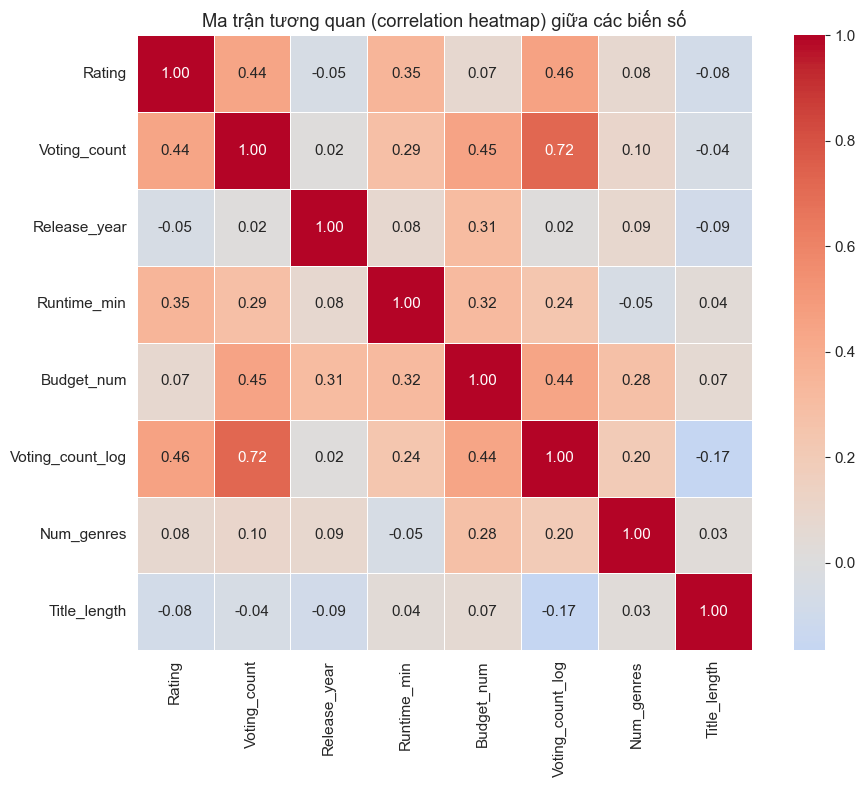

In [43]:
# Các biến số để tương quan (dùng Runtime_min đã tạo ở bước làm sạch)
num_cols = ['Rating', 'Voting_count', 'Release_year', 'Runtime_min', 'Budget_num', 'Voting_count_log', 'Num_genres', 'Title_length']
num_cols = [c for c in num_cols if c in df_clean.columns]
df_num = df_clean[num_cols].copy()
corr = df_num.corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, linewidths=0.5, ax=ax)
ax.set_title('Ma trận tương quan (correlation heatmap) giữa các biến số')
plt.tight_layout()
plt.show()

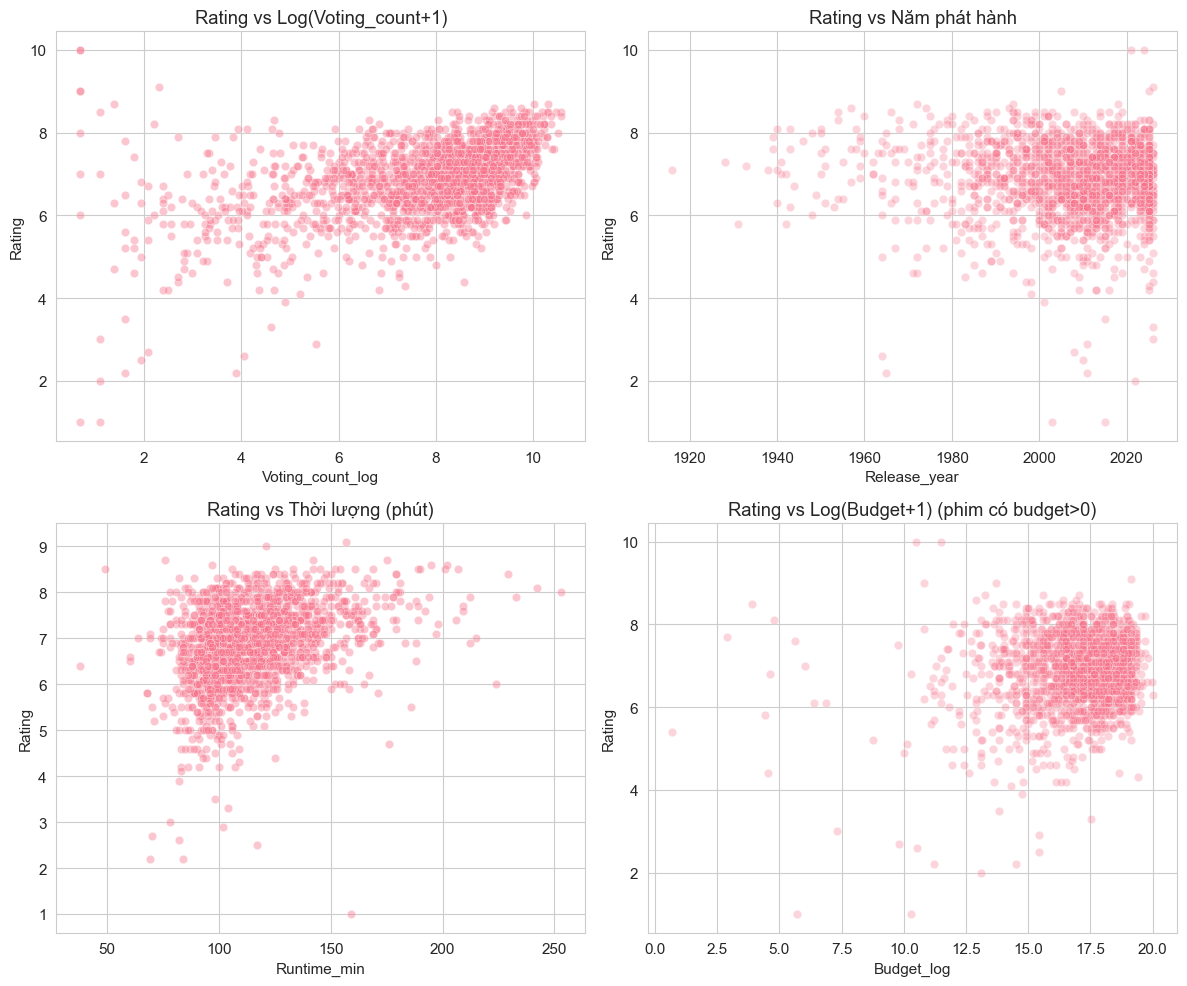

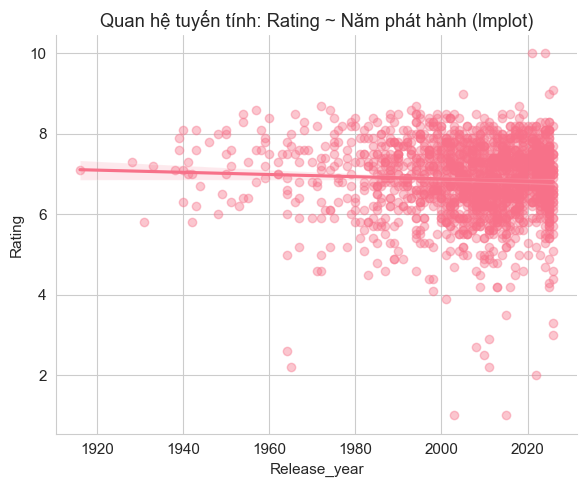

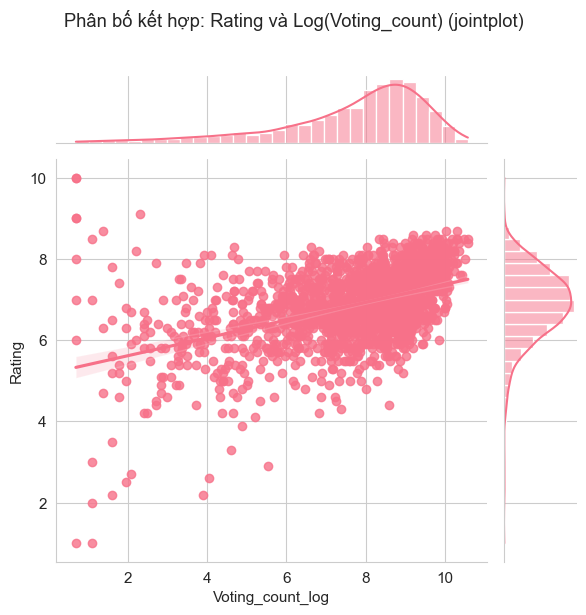

In [44]:
# Scatter + lmplot: mối quan hệ giữa Rating và các biến dự đoán
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
sns.scatterplot(data=df_clean, x='Voting_count_log', y='Rating', alpha=0.4, ax=axes[0,0])
axes[0,0].set_title('Rating vs Log(Voting_count+1)')
sns.scatterplot(data=df_clean, x='Release_year', y='Rating', alpha=0.3, ax=axes[0,1])
axes[0,1].set_title('Rating vs Năm phát hành')
sns.scatterplot(data=df_clean.dropna(subset=['Runtime_min']), x='Runtime_min', y='Rating', alpha=0.4, ax=axes[1,0])
axes[1,0].set_title('Rating vs Thời lượng (phút)')
sns.scatterplot(data=df_clean[df_clean['Budget_num'] > 0], x='Budget_log', y='Rating', alpha=0.3, ax=axes[1,1])
axes[1,1].set_title('Rating vs Log(Budget+1) (phim có budget>0)')
plt.tight_layout()
plt.show()

# lmplot: đường hồi quy tuyến tính (seaborn)
sns.lmplot(data=df_clean, x='Release_year', y='Rating', height=5, aspect=1.2, scatter_kws={'alpha': 0.4})
plt.title('Quan hệ tuyến tính: Rating ~ Năm phát hành (lmplot)')
plt.tight_layout()
plt.show()

# Distribution plot (jointplot): Rating vs Voting_count_log
sns.jointplot(data=df_clean, x='Voting_count_log', y='Rating', kind='reg', height=6, marginal_kws=dict(bins=30))
plt.suptitle('Phân bố kết hợp: Rating và Log(Voting_count) (jointplot)', y=1.02)
plt.tight_layout()
plt.show()

### Clustermap và t-SNE

- **Clustermap:** Gom nhóm các biến và mẫu theo độ tương đồng (hierarchical clustering) để thấy cấu trúc tương quan.
- **t-SNE:** Giảm chiều dữ liệu xuống 2D để trực quan hóa không gian nhiều chiều; nếu có cụm (cluster) theo rating hoặc thể loại thì có thể quan sát được.

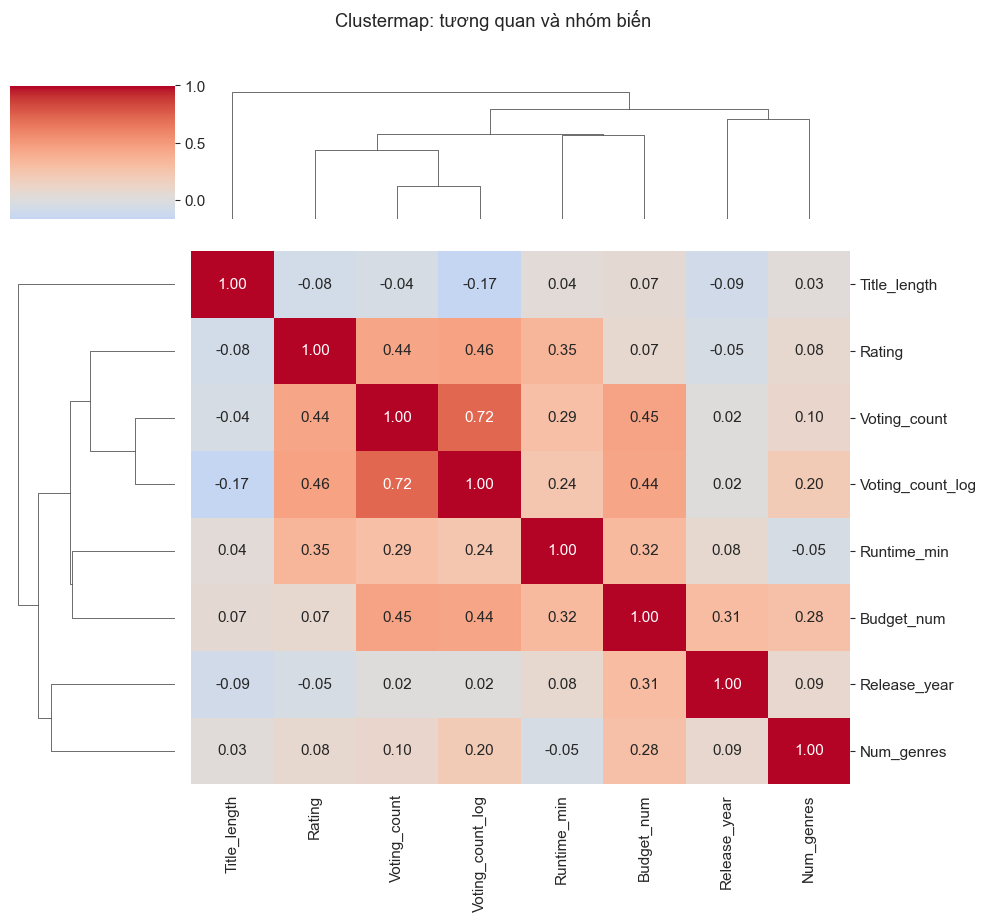

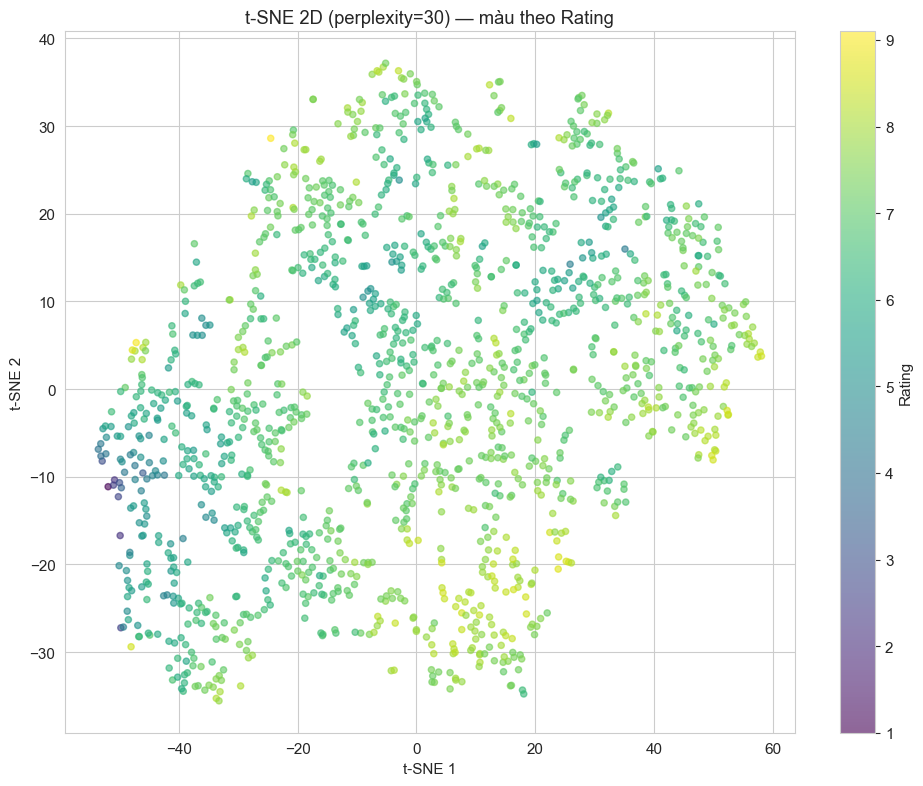

In [45]:
# Clustermap (seaborn): tương quan + hierarchical clustering
sns.clustermap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, figsize=(10, 9))
plt.suptitle('Clustermap: tương quan và nhóm biến', y=1.02)
plt.tight_layout()
plt.show()

# t-SNE: lấy mẫu để chạy nhanh (t-SNE tốn thời gian)
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

# Chỉ lấy các dòng đầy đủ num_cols (t-SNE cần dữ liệu số không missing)
df_tsne_pool = df_clean.dropna(subset=num_cols)

if len(df_tsne_pool) < 50:
    print(f'Không đủ dữ liệu để chạy t-SNE (cần >=50 dòng sau dropna, hiện có {len(df_tsne_pool)}).')
else:
    n_sample = min(1500, len(df_tsne_pool))
    df_tsne = df_tsne_pool.sample(n=n_sample, random_state=42, replace=False)

    X = df_tsne[num_cols].values
    X_scaled = StandardScaler().fit_transform(X)

    # Perplexity phải < số mẫu; chọn tự động để tránh lỗi
    perplexity = int(min(30, max(5, (len(df_tsne) - 1) // 3)))
    tsne = TSNE(n_components=2, random_state=42, perplexity=perplexity, init='pca', learning_rate='auto')

    X_2d = tsne.fit_transform(X_scaled)
    df_tsne = df_tsne.copy()
    df_tsne['tsne1'] = X_2d[:, 0]
    df_tsne['tsne2'] = X_2d[:, 1]

    fig, ax = plt.subplots(figsize=(10, 8))
    scatter = ax.scatter(df_tsne['tsne1'], df_tsne['tsne2'], c=df_tsne['Rating'], cmap='viridis', alpha=0.6, s=20)
    plt.colorbar(scatter, label='Rating')
    ax.set_title(f't-SNE 2D (perplexity={perplexity}) — màu theo Rating')
    ax.set_xlabel('t-SNE 1')
    ax.set_ylabel('t-SNE 2')
    plt.tight_layout()
    plt.show()

## 7. Kết luận

**1. Tính khả thi của bài toán (về mặt dữ liệu)**  
Bài toán **dự đoán rating phim (hồi quy)** từ các yếu tố như năm phát hành, số lượt bình chọn, thể loại, thời lượng, ngân sách là **khả thi** vì:
- Số mẫu đạt yêu cầu (>1000) và số biến ≥ 5 (Movie_name, Release_year, Rating, Voting_count, Genre, Run_time, Budget).
- Sau làm sạch, dữ liệu có kiểu rõ ràng (số, danh mục); biến mục tiêu Rating liên tục, phù hợp hồi quy.
- Trực quan đa biến cho thấy có mối quan hệ tiềm ẩn giữa Rating với Voting_count (log), Release_year, Runtime_min; correlation heatmap và lmplot hỗ trợ điều này.
- t-SNE cho thấy dữ liệu có cấu trúc (màu theo rating có xu hướng gradient), gợi ý mô hình có thể học được pattern.

**2. Tập đặc trưng hữu ích đề xuất cho mô hình**  
- **Số:** Voting_count (hoặc Voting_count_log), Release_year, Runtime_min, Budget_num (hoặc Budget_log), Num_genres, Title_length, Decade.  
- **Danh mục đã mã hóa:** Các cột one-hot thể loại (Genre_Drama, Genre_Comedy, …).  
- Có thể bổ sung tương tác (vd: Runtime × Decade) hoặc đặc trưng từ text (TF-IDF trên mô tả) trong bài tập mô hình hóa sau.

**3. Hạn chế**  
- Budget và Runtime có nhiều missing; cần xử lý (bỏ hoặc impute) khi đưa vào mô hình.  
- Voting_count lệch phải mạnh; nên dùng log khi mô hình hóa.

## 8. Tài liệu tham khảo

- The Movie Database (TMDB): https://www.themoviedb.org
- TMDB API: https://developers.themoviedb.org/3
- Feature engineering: https://phamdinhkhanh.github.io/2019/01/07/Ky_thuat_feature_engineering.html
- t-SNE: https://www.datacamp.com/tutorial/introduction-t-sne
- (Thêm các nguồn đã dùng: seaborn, pandas, scikit-learn docs, …)

In [49]:
# Lưu dữ liệu đã làm sạch — ghi cả CSV và XLSX để tránh lỡ xóa mất một file
os.makedirs(CLEAN_DIR, exist_ok=True)

df_clean.to_csv(CLEAN_PATH, index=False, encoding='utf-8-sig')
print('1. CSV:', CLEAN_PATH)

CLEAN_XLSX_PATH = os.path.join(CLEAN_DIR, 'movies_clean.xlsx')
df_clean.to_excel(CLEAN_XLSX_PATH, index=False)
print('2. XLSX:', CLEAN_XLSX_PATH)

print('Số dòng:', len(df_clean), '| Số cột:', len(df_clean.columns))

1. CSV: ..\clean data\movies_clean.csv
2. XLSX: ..\clean data\movies_clean.xlsx
Số dòng: 1806 | Số cột: 26
